In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Save model
import joblib

In [2]:
df = pd.read_csv(r"C:\Users\nitya\Downloads\archive (2)/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass']

In [7]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [8]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [9]:
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [10]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [11]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



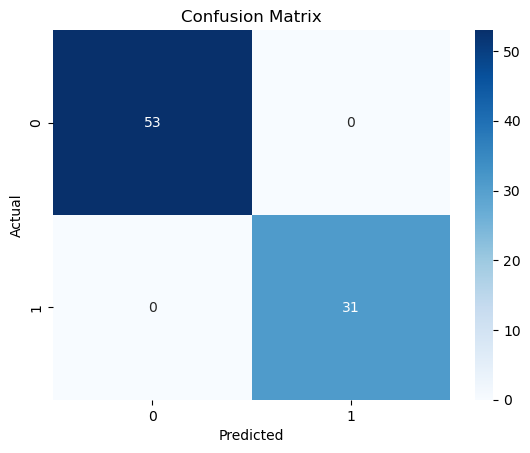

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

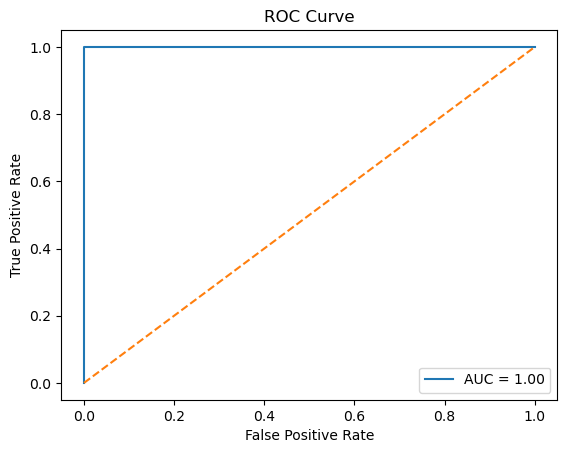

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
cv_scores = cross_val_score(
    model_pipeline, X, y, cv=5, scoring='roc_auc'
)

print(f"ROC-AUC Mean: {cv_scores.mean():.3f}")
print(f"ROC-AUC Std: {cv_scores.std():.3f}")

ROC-AUC Mean: 1.000
ROC-AUC Std: 0.000


In [16]:
joblib.dump(model_pipeline, "model.joblib")

['model.joblib']

In [17]:
loaded_model = joblib.load("model.joblib")

sample = X_test.iloc[:5]
predictions = loaded_model.predict(sample)

print(predictions)

[1 1 0 1 0]


🔹 Key Decisions
Median imputation for numeric features (robust to outliers)
Most frequent imputation for categorical
One-hot encoding for categorical variables
Standard scaling for numeric features (important for Logistic Regression)

🔹 Model Performance Interpretation
Accuracy shows overall correctness
Precision → how many predicted survived were correct
Recall → how many actual survived were detected
ROC-AUC → overall ranking ability of model

🔹 Key Takeaways (Write These as Bullets)
Gender (Sex) strongly influences survival (females more likely survived)
Passenger class (Pclass) impacts survival probability
Fare correlates with survival (wealthier passengers had better chances)
Logistic Regression gives a simple and interpreable baseline
Model performs reasonably but not perfect → dataset is small & noisy
Some features (like Cabin, Ticket) were ignored → could improve performance
Class imbalance handled using stratified split
Cross-validation ensures stable performance estimate
ROC-AUC is better than accuracy for evaluating classification quality
Pipeline ensures reproducibility and easy deployment

🔹 Limitations
Linear model → cannot capture complex patterns
Limited features used
Missing data reduces accuracy

🔹 Next Steps
Try advanced models: Random Forest, XGBoost
Feature engineering (family size, title extraction)
Hyperparameter tuning (GridSearchCV)
Handle imbalance using SMOTE or class weights